Shape: (284807, 31)

Columns:
 ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-nul

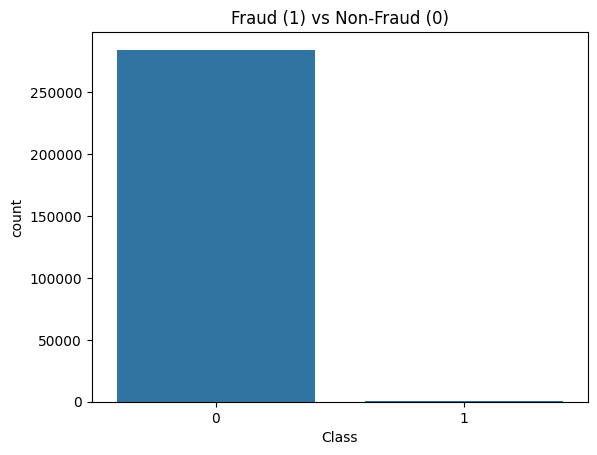

In [1]:
# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/Users/shivammarkanday/Library/CloudStorage/OneDrive-AdaniUniversity/SEMESTERS/SEM 5 (2025)/Machine Learning (ML)/Project/fraud_detection/data/creditcard.csv")

# Basic info
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nInfo:\n")
df.info()

# Missing values check
print("\nMissing values:\n", df.isnull().sum().sum())

# Class distribution
print("\nClass distribution:\n", df['Class'].value_counts())

# Plot class imbalance
sns.countplot(x='Class', data=df)
plt.title("Fraud (1) vs Non-Fraud (0)")
plt.show()


In [2]:
# Preprocessing and Train-Test Split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop 'Time' (not useful for prediction)
X = df.drop(columns=['Class', 'Time'])
y = df['Class']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train & test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Fraud ratio in training data:", y_train.mean())
print("Fraud ratio in test data:", y_test.mean())


Train shape: (227845, 29)
Test shape: (56962, 29)
Fraud ratio in training data: 0.001729245759178389
Fraud ratio in test data: 0.0017204452090867595


In [3]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_res))


Before SMOTE: Counter({0: 227451, 1: 394})
After SMOTE: Counter({0: 227451, 1: 227451})


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Train model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_res, y_train_res)

# Predict on test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))


Confusion Matrix:
 [[55343  1521]
 [    8    90]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9999    0.9733    0.9864     56864
           1     0.0559    0.9184    0.1053        98

    accuracy                         0.9732     56962
   macro avg     0.5279    0.9458    0.5458     56962
weighted avg     0.9982    0.9732    0.9849     56962

ROC AUC Score: 0.9706022532817291


Confusion Matrix:
 [[56790    74]
 [   15    83]]

Classification Report:
               precision    recall  f1-score   support

           0     0.9997    0.9987    0.9992     56864
           1     0.5287    0.8469    0.6510        98

    accuracy                         0.9984     56962
   macro avg     0.7642    0.9228    0.8251     56962
weighted avg     0.9989    0.9984    0.9986     56962

ROC AUC Score: 0.9831307135966373


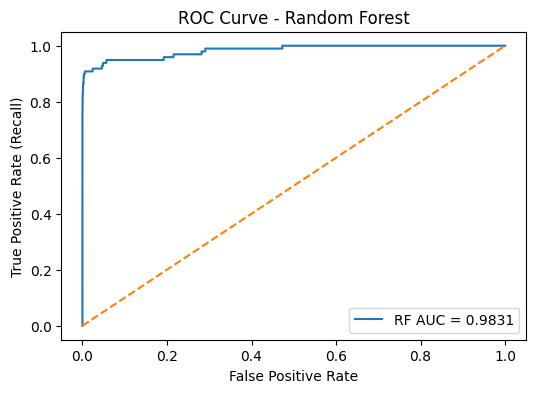

Top 10 features (importance):
V14: 0.1674
V10: 0.1603
V4: 0.1253
V12: 0.1046
V11: 0.0794
V17: 0.0692
V7: 0.0411
V3: 0.0402
V16: 0.0329
V2: 0.0210


['../models/scaler.joblib']

In [6]:
# Random Forest training + eval
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import joblib
import matplotlib.pyplot as plt
import numpy as np

rf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)

# Predict
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

# Metrics
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, digits=4))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob_rf))

# ROC curve (optional plot)
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'RF AUC = {roc_auc_score(y_test, y_prob_rf):.4f}')
plt.plot([0,1],[0,1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()

# Feature importances (top 10)
fi = rf.feature_importances_
feat_names = X.columns if isinstance(X, pd.DataFrame) else [f'feat_{i}' for i in range(X.shape[1])]
idx = np.argsort(fi)[-10:][::-1]
print("Top 10 features (importance):")
for i in idx:
    print(f"{feat_names[i]}: {fi[i]:.4f}")

# Save model + scaler
joblib.dump(rf, "../models/rf_fraud_model.joblib")
joblib.dump(scaler, "../models/scaler.joblib")

